In [1]:
import os
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
from scipy.stats import ttest_1samp
from scipy.ndimage import gaussian_filter

import cmocean
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.colors as mcolors

In [2]:
class SoilMoistureDifferencePlotter:
    def __init__(self, data_dict, landmask_file=None, soilayer_file=None,
                 variable='H2OSOI', dz_var='DZSOI', landmask_var='landfrac',
                 depth_cm=10, mask_land=True, confidence_level=0.05,
                 use_mass_units=True):
        self.data_dict = data_dict
        self.variable = variable
        self.dz_var = dz_var
        self.landmask_var = landmask_var
        self.depth_cm = depth_cm
        self.mask_land = mask_land
        self.significance_threshold = confidence_level
        self.confidence_level = confidence_level
        self.use_mass_units = use_mass_units
        self.water_density = 1000.0
        
        self.landmask = None
        if landmask_file and os.path.exists(landmask_file):
            ds_mask = xr.open_dataset(landmask_file)
            self.landmask = ds_mask['landmask']
        
            # Detect longitude coordinate name (case-insensitive)
            lon_name = None
            lower_coords = {k.lower(): k for k in self.landmask.coords}
            for test in ['lon', 'longitude']:
                if test in lower_coords:
                    lon_name = lower_coords[test]
                    break
        
            # Convert to 0–360 if needed
            if lon_name:
                lon = self.landmask[lon_name]
                if lon.min() < 0 or lon.max() > 360:
                    new_lon = (lon % 360).sortby(lon)
                    self.landmask = self.landmask.assign_coords({lon_name: new_lon})
                    self.landmask = self.landmask.sortby(lon_name)

    
        self.fixed_dz = None
        if soilayer_file and os.path.exists(soilayer_file):
            self.fixed_dz = xr.open_dataset(soilayer_file)[dz_var]

    def _load_dataset(self, info, year, ensemble=None):
        template = info['template']
        path = info['path']
        filename = template % {'year': year, 'ensemble': ensemble} if ensemble else template % {'year': year}
        full_path = os.path.join(path, filename)
        if not os.path.exists(full_path):
            raise FileNotFoundError(f"[ERROR] File not found: {full_path}")
        ds = xr.open_dataset(full_path)

        return ds 

    def normalize_longitude_and_sort(self, ds, lon_name='lon'):
        """
        Normalize longitude in the dataset to [-180, 180] and sort by longitude.
    
        Parameters
        ----------
        ds : xr.DataArray or xr.Dataset
            Input data with a longitude coordinate.
        lon_name : str, default='lon'
            Name of the longitude coordinate.
    
        Returns
        -------
        xr.DataArray or xr.Dataset
            Dataset with normalized and sorted longitude.
        """
        if lon_name in ds.coords:
            lon = ds[lon_name]
            if lon.max() > 180:
                print("[INFO] Normalizing longitude to [-180, 180].")
                ds[lon_name] = ((lon + 180) % 360) - 180
                ds = ds.sortby(lon_name)
        return ds
    
    
    def _wrap_longitude_for_plot(self, da):
        """Append one column to wrap around at 180° for seamless plotting."""
        if 'lon' not in da.coords:
            return da
        if da.lon.max() > 180 or da.lon.min() < -180:
            return da  # already in 0–360 or irregular
        lon = da.lon
        if lon[0] < -179 and lon[-1] > 179:
            wrapped = da.pad(lon=(0, 1), constant_values=np.nan)
            wrapped['lon'][-1] = wrapped['lon'][0] + 360
            return wrapped
        return da
        
    def _integrate_top_layers(self, ds):
        sm = ds[self.variable]

        if self.dz_var in ds:
            dz = ds[self.dz_var]
            if "time" in dz.dims:
                dz = dz.isel(time=0)
        elif self.fixed_dz is not None:
            dz = self.fixed_dz
        else:
            raise ValueError("No valid DZSOI found in dataset or external source.")

        dz_cumsum = dz.cumsum(dim='levgrnd')
        top_mask = dz_cumsum <= (self.depth_cm / 100.0)
        sm_top = sm.where(top_mask)
        dz_masked = dz.where(top_mask)
        if self.use_mass_units:
            sm_mass = sm_top * dz_masked * self.water_density
            integrated = sm_mass.sum(dim='levgrnd')
            integrated.attrs['units'] = 'kg/m2'
        else:
            integrated = (sm_top * dz_masked).sum(dim='levgrnd') / dz_masked.sum(dim='levgrnd')
            integrated.attrs['units'] = 'm3/m3'

        if self.landmask is not None:
            integrated = integrated.where(self.landmask > 0.1)

        return integrated

    def _load_model_ensemble_snapshot(self, model_info, target_date):
        nens = model_info['nens']
        ens_data = []
        for n in range(1, nens + 1):
            ens = f'EN{n:02d}'
            ds = self._load_dataset(model_info, target_date.year, ensemble=ens)
            ds_day = ds.sel(time=target_date)
            sm_top = self._integrate_top_layers(ds_day)
            ens_data.append(sm_top.squeeze())
        return xr.concat(ens_data, dim='ensemble')

    def _load_obs_snapshot(self, obs_info, target_date):
        ds = self._load_dataset(obs_info, target_date.year)
        obs = ds[self.variable].sel(time=target_date)
    
        # Detect longitude coordinate name (case-insensitive)
        lon_name = None
        lower_coords = {k.lower(): k for k in obs.coords}
        for test in ['lon', 'longitude']:
            if test in lower_coords:
                lon_name = lower_coords[test]
                break
                
        # Convert longitude from [-180, 180] to [0, 360] if needed
        if lon_name:
            lon = obs[lon_name]
            if lon.min() < 0 or lon.max() > 360:
                new_lon = (lon % 360).sortby(lon)
                obs = obs.assign_coords({lon_name: new_lon})
                obs = obs.sortby(lon_name)
    
        if self.use_mass_units:
            obs = obs * 1000.0 * self.depth_cm / 100.0
    
        if self.landmask is not None:
            obs = obs.where(self.landmask > 0.1)
    
        return obs

    def _wrap_longitude_for_plot(self, da):
        if 'lon' not in da.coords:
            return da
    
        lon = da.lon
        if (lon[-1] - lon[0]) < 359:  # Avoid double-padding
            da = da.pad(lon=(0, 1), constant_values=np.nan)
            da['lon'][-1] = da['lon'][0] + 360  # Wrap around
        return da
        
    def _compute_significance_mask(self, ensemble_data, obs_mean, alpha=0.05, threshold=None):
        if threshold is None:
            threshold = self.significance_threshold

        diff = ensemble_data - obs_mean
        tstat, pvals = ttest_1samp(diff.transpose("ensemble", "lat", "lon").values,
                                   popmean=0.0, axis=0, nan_policy='omit')

        sig_mask = xr.DataArray(pvals < alpha, coords=obs_mean.coords, dims=obs_mean.dims)
        model_mean = ensemble_data.mean(dim='ensemble')
        valid_mask = (abs(model_mean) > threshold) & (abs(obs_mean) > threshold)
        return sig_mask.where(valid_mask)

    def plot_bias_and_stddev_multi_panel(self, model_keys, target_date='2012-01-01',
                                         obs_key='ESA_CCI', bias_levels=None, spread_levels=None,
                                         cmap_bias='RdBu_r', cmap_std='viridis',
                                         figsize=(12, 5), savepath=None, fontz=8):
        target_date = pd.to_datetime(target_date)
        ncols = len(model_keys)
    
        if bias_levels is None:
            bias_levels = [-0.5, -0.3, -0.1, -0.05, -0.01, 0.01, 0.05, 0.1, 0.3, 0.5]
        if spread_levels is None:
            spread_levels = [0.005, 0.01, 0.02, 0.04, 0.06, 0.08, 0.1]
    
        bias_cmap = mpl.colors.ListedColormap(plt.get_cmap(cmap_bias)(np.linspace(0, 1, len(bias_levels) - 1)))
        bias_norm = mcolors.BoundaryNorm(bias_levels, ncolors=bias_cmap.N)
        spread_cmap = mpl.colors.ListedColormap(plt.get_cmap(cmap_std)(np.linspace(0, 1, len(spread_levels) - 1)))
        spread_norm = mcolors.BoundaryNorm(spread_levels, ncolors=spread_cmap.N)
    
        fig, axes = plt.subplots(
            nrows=2, ncols=ncols, figsize=figsize,
            subplot_kw={'projection': ccrs.Robinson()},
            constrained_layout=False
        )
    
        for j, model_key in enumerate(model_keys):
            model_info = self.data_dict[model_key]
            obs_info = self.data_dict[obs_key]
    
            ens_stack = self._load_model_ensemble_snapshot(model_info, target_date)
            obs_field = self._load_obs_snapshot(obs_info, target_date)
    
            if ens_stack.shape[1:] != obs_field.shape:
                ens_stack = ens_stack.interp_like(obs_field)
    
            model_mean = ens_stack.mean(dim='ensemble')
            model_std = ens_stack.std(dim='ensemble')
            bias = model_mean - obs_field
            
            model_mean = self._wrap_longitude_for_plot(model_mean)
            bias = self._wrap_longitude_for_plot(bias)
            model_std = self._wrap_longitude_for_plot(model_std)
            
            model_vals = model_mean.values.flatten()
            obs_vals = obs_field.values.flatten()
            valid = np.isfinite(model_vals) & np.isfinite(obs_vals)
            pcc = np.corrcoef(model_vals[valid], obs_vals[valid])[0, 1]
            rmse_val = float(np.sqrt(((model_vals[valid] - obs_vals[valid]) ** 2).mean()))
    
            # Bias panel
            ax0 = axes[0, j]
            cf = ax0.contourf(
                bias['lon'], bias['lat'], bias.values,
                levels=bias_levels,
                cmap=bias_cmap,
                norm=bias_norm,
                transform=ccrs.PlateCarree()
            )
    
            ax0.set_title(f"{model_key} - {obs_key} (Bias)", fontsize=fontz)
            ax0.coastlines(linewidth=0.4)
            ax0.tick_params(labelsize=fontz - 1)
            
            ax0.text(
                0.98, 0.02, f"PCC: {pcc:.2f}\nRMSE: {rmse_val:.2f}",
                transform=ax0.transAxes, fontsize=fontz - 2, va='bottom', ha='right',
                bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.1')
            )
    
            sig_mask = self._compute_significance_mask(ens_stack, obs_field, alpha=self.confidence_level)
            sig_mask.plot.contourf(
                ax=ax0, transform=ccrs.PlateCarree(),
                colors='none', hatches=['..', '..'], 
                add_colorbar=False, 
                add_labels=False,
                linewidths=0
            )
    
            # Spread panel
            ax1 = axes[1, j]
            cf = ax1.contourf(
                model_std['lon'], model_std['lat'], model_std,
                levels=spread_levels,
                cmap=spread_cmap,
                norm=spread_norm,
                transform=ccrs.PlateCarree(),
                extend='both'
            )

            ax1 = axes[1, j]
            model_std.plot.pcolormesh(
                ax=ax1, transform=ccrs.PlateCarree(),
                cmap=spread_cmap, 
                norm=spread_norm, 
                add_labels=False,
                add_colorbar=False
            )
    
            ax1.set_title(f"{model_key} (Spread)", fontsize=fontz)
            ax1.coastlines(linewidth=0.4)
            ax1.tick_params(labelsize=fontz - 1)
    
        # Adjust layout
        plt.subplots_adjust(wspace=0.1, right=0.88, hspace=0.2)
    
        # Bias colorbar
        cbar_ax1 = fig.add_axes([0.90, 0.60, 0.01, 0.30])
        sm1 = mpl.cm.ScalarMappable(norm=bias_norm, cmap=bias_cmap)
        sm1.set_array(np.array([0]))
        
        # Select every 2nd tick from bias_levels for labels
        ticks_to_show = bias_levels[::1]
        
        cb1 = fig.colorbar(sm1, cax=cbar_ax1, ticks=ticks_to_show,
                           extend='both',  # Show triangle only on the upper end (change to 'both' if needed)
                           label="Bias (kg m$^{-2}$)" if self.use_mass_units else "Bias (m$^3$ m$^{-3}$)")
        cbar_ax1.yaxis.label.set_size(fontz)
        cbar_ax1.tick_params(labelsize=fontz - 1)
    
        # Spread colorbar
        cbar_ax2 = fig.add_axes([0.90, 0.18, 0.01, 0.30])
        sm2 = mpl.cm.ScalarMappable(norm=spread_norm, cmap=spread_cmap)
        sm2.set_array(np.array([0]))
        cb2 = fig.colorbar(sm2, cax=cbar_ax2, ticks=spread_levels,
                           extend='both',  # Show triangle only on the upper end (change to 'both' if needed)
                           label="Spread (kg m$^{-2}$)" if self.use_mass_units else "Spread (m$^3$ m$^{-3}$)")
        cbar_ax2.yaxis.label.set_size(fontz)
        cbar_ax2.tick_params(labelsize=fontz - 1)
    
        plt.subplots_adjust(hspace=0.15, wspace=0.05)
        plt.show()
    
        if savepath:
            fig.savefig(savepath, dpi=600, bbox_inches='tight')
            print(f"[SAVED] Figure saved to: {savepath}")



/global/common/software/e3sm/anaconda_envs/base/envs/e3sm_unified_1.10.0_login/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:577: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  return result_to_tuple(hypotest_fun_out(*samples, **kwds))
/global/common/software/e3sm/anaconda_envs/base/envs/e3sm_unified_1.10.0_login/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:1642: UserWarning: linewidths is ignored by contourf
  result = super().contourf(*args, **kwargs)
/global/common/software/e3sm/anaconda_envs/base/envs/e3sm_unified_1.10.0_login/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:1642: UserWarning: linewidths is ignored by contourf
  result = super().contourf(*args, **kwargs)


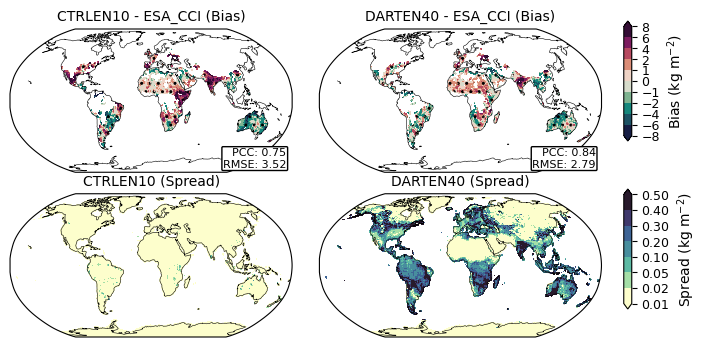

[SAVED] Figure saved to: /global/homes/z/zhan391/analysis/diagnostic/figures/sm_bias_stddev_vs_ESA_CCI_20120101.png


In [3]:
if __name__ == "__main__":
    # Paths
    top_path = "/global/cfs/cdirs/m4849/zhan391/e3sm_dart"
    out_path = os.path.join(top_path, "diag_dart_backup")
    fig_path = "/global/homes/z/zhan391/analysis/diagnostic/figures"
    os.makedirs(fig_path, exist_ok=True)

    landmask_file = os.path.join(out_path, "landmask_1x1.nc")
    soilayer_file = os.path.join(out_path, "dzsoi_elm.nc")

    # Data sources
    data_dict = {
        'CPC_SOM': {
            'path': f'{top_path}/Observations/CPC_SOM/monthly',
            'template': 'SOILWATER_10CM.daily.%(year)s.nc',
            'frequency': 'monthly',
            'nens': 1
        },
        'ESA_CCI': {
            'path': f'{top_path}/Observations/ESA_CCI/daily',
            'template': 'H2OSOI.daily.%(year)s.nc',
            'frequency': 'daily',
            'nens': 1
        },
        'CTRLEN10': {
            'path': f'{top_path}/CTRLEN10_15day_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy/archive/post/lnd/180x360_aave/ts/daily',
            'template': 'H2OSOI.%(ensemble)s.%(year)s.nc',
            'frequency': 'daily',
            'nens': 10
        },
        'CAPTEN10': {
            'path': f'{top_path}/CAPTEN10_15day_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy/archive/post/lnd/180x360_aave/ts/daily',
            'template': 'H2OSOI.%(ensemble)s.%(year)s.nc',
            'frequency': 'daily',
            'nens': 10
        },
        'DARTEN20': {
            'path': f'{top_path}/DARTEN20_15day_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy/archive/post/lnd/180x360_aave/ts/daily',
            'template': 'H2OSOI.%(ensemble)s.%(year)s.nc',
            'frequency': 'daily',
            'nens': 20
        },
        'DARTEN40': {
            'path': f'{top_path}/DARTEN40_15day_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy/archive/post/lnd/180x360_aave/ts/daily',
            'template': 'H2OSOI.%(ensemble)s.%(year)s.nc',
            'frequency': 'daily',
            'nens': 40
        }
    }

    # Configuration
    model_keys = ['CTRLEN10', 'CAPTEN10', 'DARTEN20', 'DARTEN40']
    model_keys = ['CTRLEN10', 'DARTEN40']

    target_date = '2012-01-01'
    obs_key = 'ESA_CCI'
    bias_levels = [-8, -6, -4, -2, -1, 0, 1, 2, 4, 6, 8]
    spread_levels = [0.01, 0.02, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5]
    fontz = 10
    figsize=(8, 4)
    
    combined_savefile = os.path.join(
        fig_path, f"sm_bias_stddev_vs_{obs_key}_{target_date.replace('-', '')}.png"
    )

    # Plotter
    plotter = SoilMoistureDifferencePlotter(
        data_dict=data_dict,
        landmask_file=landmask_file,
        soilayer_file=soilayer_file,
        depth_cm=5,
        mask_land=True,
        confidence_level=0.05,
        use_mass_units=True
    )

    plotter.plot_bias_and_stddev_multi_panel(
        model_keys=model_keys,
        target_date=target_date,
        obs_key=obs_key,
        bias_levels=bias_levels,
        spread_levels=spread_levels,
        figsize=figsize,
        fontz=fontz,
        cmap_bias=cmocean.cm.curl,
        cmap_std=cmocean.cm.deep,
        savepath=combined_savefile
    )